In [58]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

### Loading the dataset

In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.ImageFolder("/kaggle/input/timgnet/train", transform=transform)
test_dataset  = datasets.ImageFolder("/kaggle/input/timgnet/test",  transform=transform)

batch_size = 512

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

print(f"Classes: {train_dataset.classes}")
print(f"Train size: {len(train_dataset)}, Val size: {len(test_dataset)}")

Classes: ['n07871810', 'n07873807', 'n07875152', 'n07920052', 'n09193705', 'n09246464', 'n09256479', 'n09332890', 'n09428293', 'n12267677']
Train size: 3500, Val size: 1000


In [3]:
train_dataset[0][0].shape

torch.Size([3, 64, 64])

### Defining Model A architecture

In [49]:
class CNN(nn.Module): # inherit from nn.Module
    def __init__(self):
        super().__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv5 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv6 = nn.Conv2d(128, 128, 3, padding=1)
        self.conv7 = nn.Conv2d(128, 256, 8, padding=0)

        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)

        self.fc1 = nn.Linear(256, 64)
        self.fc2 = nn.Linear(64, 10)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)
        
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.pool(x)
        
        x = F.relu(self.conv7(x))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

    
    # for predicting the digit
    def predict(self, x):
        with torch.no_grad(): # disable gradient tracking during inference
            logits = self(x) # get raw class scores (logits) 
            predictions = torch.argmax(logits, dim=1) # select the one with highest logit
            return predictions

In [50]:
modelA = CNN().to(device)

### Defining the loss function and optimizer

In [6]:
optimizer = optim.Adam(modelA.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

### Model training

In [7]:
history = []
modelA.train()
for epoch in range(100):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()    
        outputs = modelA(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    history.append(running_loss/len(train_loader))
    print(f"Epoch {epoch + 1}, Loss={loss.item():}")

Epoch 1, Loss=2.2366061210632324
Epoch 2, Loss=1.992784023284912
Epoch 3, Loss=1.8914555311203003
Epoch 4, Loss=1.8603078126907349
Epoch 5, Loss=1.7505062818527222
Epoch 6, Loss=1.7780402898788452
Epoch 7, Loss=1.7486615180969238
Epoch 8, Loss=1.6933014392852783
Epoch 9, Loss=1.6930553913116455
Epoch 10, Loss=1.6661865711212158
Epoch 11, Loss=1.652282953262329
Epoch 12, Loss=1.620062232017517
Epoch 13, Loss=1.6099098920822144
Epoch 14, Loss=1.6121912002563477
Epoch 15, Loss=1.6024266481399536
Epoch 16, Loss=1.587600827217102
Epoch 17, Loss=1.3907172679901123
Epoch 18, Loss=1.4068763256072998
Epoch 19, Loss=1.4079864025115967
Epoch 20, Loss=1.4244424104690552
Epoch 21, Loss=1.2975376844406128
Epoch 22, Loss=1.3863744735717773
Epoch 23, Loss=1.2344434261322021
Epoch 24, Loss=1.2663480043411255
Epoch 25, Loss=1.2523444890975952
Epoch 26, Loss=1.1972895860671997
Epoch 27, Loss=1.248874545097351
Epoch 28, Loss=1.0805705785751343
Epoch 29, Loss=1.064241647720337
Epoch 30, Loss=1.015792369842

### Plot of Loss vs epochs

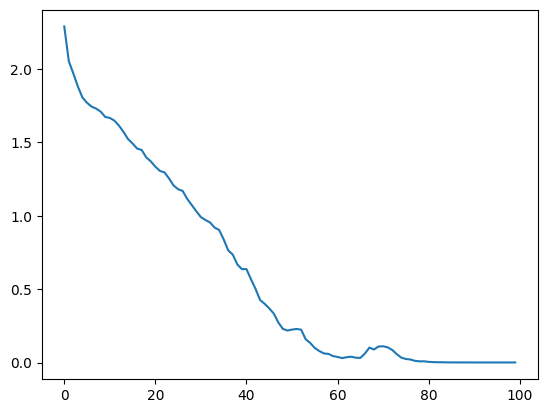

In [8]:
plt.plot(history)

### Evaluating model A

In [9]:
modelA.eval()   # set model to evaluation mode

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = modelA(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 51.50%


### Defining Model B architecture

In [51]:
class CNN2(nn.Module): # inherit from nn.Module
    def __init__(self):
        super().__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv5 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv6 = nn.Conv2d(128, 128, 3, padding=1)
        self.conv7 = nn.Conv2d(128, 256, 8, padding=0)

        # BatchNorm layers
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(32)
        self.bn3 = nn.BatchNorm2d(64)
        self.bn4 = nn.BatchNorm2d(64)
        self.bn5 = nn.BatchNorm2d(128)
        self.bn6 = nn.BatchNorm2d(128)
        self.bn7 = nn.BatchNorm2d(256)


        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)

        # (temporary — will adjust after dimension check)
        self.fc1 = nn.Linear(256, 64)
        self.fc2 = nn.Linear(64, 10)


    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool(x)
        
        x = F.relu(self.bn7(self.conv7(x)))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

    
    # for predicting the digit
    def predict(self, x):
        with torch.no_grad(): # disable gradient tracking during inference
            logits = self(x) # get raw class scores (logits) 
            predictions = torch.argmax(logits, dim=1) # select the one with highest logit
            return predictions

In [53]:
modelB = CNN2().to(device)

In [12]:
optimizer2 = optim.Adam(modelB.parameters(), lr=0.001)
criterion2 = nn.CrossEntropyLoss()

### Training Model B

In [13]:
history2 = []
modelB.train()
for epoch in range(100):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer2.zero_grad()    
        outputs = modelB(images)
        loss = criterion2(outputs, labels)
        loss.backward()
        optimizer2.step()

        running_loss += loss.item()
    
    history2.append(running_loss/len(train_loader))
    print(f"Epoch {epoch + 1}, Loss={loss.item():}")

Epoch 1, Loss=1.6074118614196777
Epoch 2, Loss=1.2655435800552368
Epoch 3, Loss=1.1971406936645508
Epoch 4, Loss=1.0032539367675781
Epoch 5, Loss=0.8990024924278259
Epoch 6, Loss=0.775062620639801
Epoch 7, Loss=0.6081444621086121
Epoch 8, Loss=0.5720820426940918
Epoch 9, Loss=0.40594375133514404
Epoch 10, Loss=0.2645978629589081
Epoch 11, Loss=0.1848020702600479
Epoch 12, Loss=0.109429731965065
Epoch 13, Loss=0.05861559510231018
Epoch 14, Loss=0.028470071032643318
Epoch 15, Loss=0.019180957227945328
Epoch 16, Loss=0.010542485862970352
Epoch 17, Loss=0.00785443838685751
Epoch 18, Loss=0.004451499320566654
Epoch 19, Loss=0.0032388123217970133
Epoch 20, Loss=0.0026007937267422676
Epoch 21, Loss=0.002365533262491226
Epoch 22, Loss=0.0018429012270644307
Epoch 23, Loss=0.0015478454297408462
Epoch 24, Loss=0.00140279158949852
Epoch 25, Loss=0.0014520147815346718
Epoch 26, Loss=0.0012340642279013991
Epoch 27, Loss=0.001106163370423019
Epoch 28, Loss=0.0011530430056154728
Epoch 29, Loss=0.00097

### Plot of loss vs epochs for model B

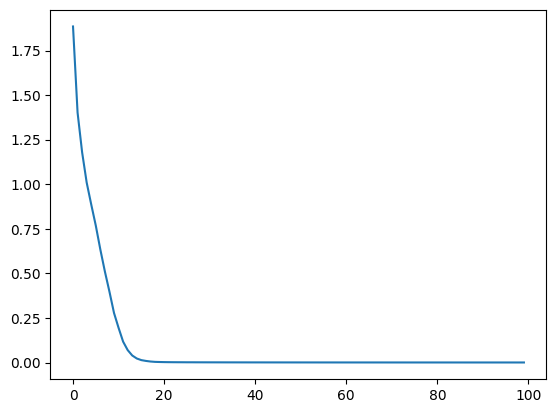

In [14]:
plt.plot(history2)

### Evaluating Model B

In [15]:
modelB.eval()   # set model to evaluation mode

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = modelB(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 63.40%


### Function to get the mean and variance of activations after nth layer, for given number of batches

In [63]:
def collect_activation_stats(model, layer, loader, device, num_batches=500):
    model.eval()

    means = []
    variances = []
    batch_counter = 0

    def hook_fn(module, inp, out):
        means.append(out.mean().item())
        variances.append(out.var().item())

    handle = layer.register_forward_hook(hook_fn)

    while(batch_counter<num_batches):
        with torch.no_grad():
            for images, _ in loader:
                images = images.to(device)
                _ = model(images)
    
                batch_counter += 1
                if batch_counter >= num_batches:
                    break

    handle.remove()
    return means, variances


In [64]:
means_A, vars_A = collect_activation_stats(modelA, modelA.conv5, train_loader, device2)
means_B, vars_B = collect_activation_stats(modelB, modelB.conv5, train_loader, device2)

### Plotting the Means and variance across different batches

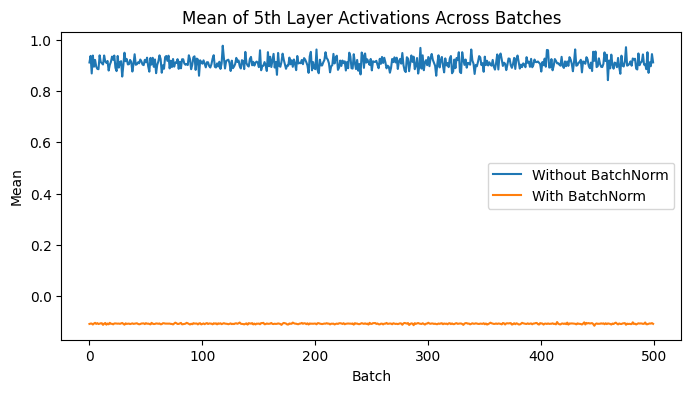

In [65]:
plt.figure(figsize=(8,4))
plt.plot(means_A, label="Without BatchNorm")
plt.plot(means_B, label="With BatchNorm")
plt.title("Mean of 5th Layer Activations Across Batches")
plt.xlabel("Batch")
plt.ylabel("Mean")
plt.legend()
plt.show()

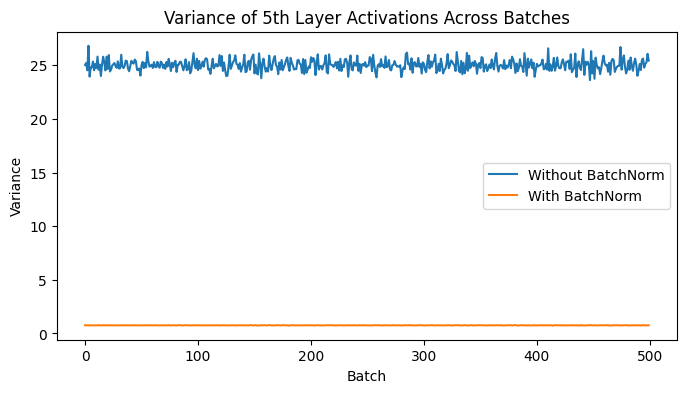

In [66]:
plt.figure(figsize=(8,4))
plt.plot(vars_A, label="Without BatchNorm")
plt.plot(vars_B, label="With BatchNorm")
plt.title("Variance of 5th Layer Activations Across Batches")
plt.xlabel("Batch")
plt.ylabel("Variance")
plt.legend()
plt.show()


### Calculating the statistics of means and variances for model A and model B

In [73]:
print(f"Mean of means_A: {np.mean(means_A):.4f}, Std: {np.std(means_A):.4f}")
print(f"Mean of means_B: {np.mean(means_B):.4f}, Std: {np.std(means_B):.4f}")
print(f"Mean of vars_A: {np.mean(vars_A):.4f}, Std: {np.std(vars_A):.4f}")
print(f"Mean of vars_B: {np.mean(vars_B):.4f}, Std: {np.std(vars_B):.4f}")

Mean of means_A: 0.9109, Std: 0.0212
Mean of means_B: -0.1090, Std: 0.0018
Mean of vars_A: 25.0316, Std: 0.5255
Mean of vars_B: 0.7597, Std: 0.0097
